# 05. 카메라–LiDAR 융합: 2D 박스 → 3D 위치·크기 (Phase 5, 6)

**목표**: YOLO 2D 박스(Phase 4) 안에 투영되는 LiDAR 점(Phase 3)을 골라 물체의 **3D 중심**과 **크기**를 추정한다.
Phase 5 는 "박스 안 점의 깊이 통계" 만 쓰는 기준선(raw), Phase 6 는 ROI → 지면 제거 → 프러스텀 → DBSCAN → 표면 오프셋으로 개선한 방법(clustered) 이다.

| 질문 | 답 |
|---|---|
| 입력은? | `points` (N, 4) float32 Velodyne [x, y, z, r], `Detection2D` 리스트 (xyxy 픽셀), `KittiCalibration` |
| 출력은? | `Object3D` 리스트 — `center` (3,) m, `size` (3,) [l, w, h], `yaw`, `n_points`, `status` ∈ ok/empty/sparse/invalid |
| 좌표계는? | 점 선택은 **이미지 픽셀** (투영), 중심·크기는 **Velodyne** (x 전방, y 좌, z 상). GT(tracklet) 도 Velodyne 이라 바로 비교 |
| 핵심 알고리즘은? | raw: 하위 30% 깊이 ± 1.5 m 밴드의 중앙값. clustered: RANSAC 지면 제거 + DBSCAN 최대 클러스터 + 시선 방향 표면→중심 오프셋 |
| 실패 사례는? | 박스 안 점 0개(멀리·작은 물체), 배경 오염(뒤 건물), 겹친 박스(같은 차에 2개 박스), 잘린 박스, 클러스터 오선택 |
| 평가는? | GT 중심과 BEV 거리 매칭 → 중심 오차·깊이 bias·재현율/정밀도 (`scripts/compare_fusion.py` → `outputs/phase6/comparison.md`) |

코드: `src/perceptrack3d/fusion/point_filters.py`, `fusion/frustum_fusion.py`. 테스트: `tests/test_fusion.py`.

In [1]:
import sys
import numpy as np
import cv2
import matplotlib.pyplot as plt

from perceptrack3d.config import load_config
from perceptrack3d.data.kitti_loader import KittiDataset
from perceptrack3d.geometry.calibration import KittiCalibration
from perceptrack3d.geometry.projection import project_velo_to_image
from perceptrack3d.detection.detector import load_detections_json
from perceptrack3d.fusion.point_filters import (roi_filter, remove_ground, shrink_box, uv_in_box,
                                                 cluster_points, aabb_from_points, obb_from_points_bev)
from perceptrack3d.fusion.frustum_fusion import fuse_frame_raw, fuse_frame_clustered, surface_to_center_offset
from perceptrack3d.evaluation.tracklets import gt_boxes_by_frame, gt_in_front_fov, box_corners_bev
from perceptrack3d.visualization.boxes2d import draw_detections
from perceptrack3d.visualization.overlay import draw_projected_points
from perceptrack3d.visualization.fusion_viz import draw_fusion, plot_bev_objects
%matplotlib inline
# (visualization 모듈이 import 시 matplotlib.use("Agg") 를 호출하므로, import 뒤에 inline 백엔드로 되돌린다)

cfg = load_config()
ds = KittiDataset(cfg)
calib = KittiCalibration.from_dir(cfg["dataset"]["calib_dir"])
dets_all = load_detections_json(f"{cfg['outputs']['dir']}/phase4/detections.json")
gts_all = gt_boxes_by_frame(ds.tracklets_path)

FRAME = 174          # 검출 7개: 정상·중복·배경 오염·클러스터 오선택이 한 프레임에 모두 있다
fr = ds.load_frame(FRAME)
img, pts = fr["image"], fr["points"]
dets = dets_all[FRAME]
gts = [b for b in gt_in_front_fov(gts_all[FRAME]) if b.center[0] <= cfg["fusion"]["roi"]["x_max"]]
print("image", img.shape, img.dtype, "| points", pts.shape, pts.dtype, "| detections", len(dets), "| GT (FOV 안, ≤70 m)", len(gts))
for k, d in enumerate(dets):
    print(f"  det{k}: {d.class_name:<4} conf={d.confidence:.2f} xyxy={np.round(d.xyxy).astype(int)}")

Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


image (375, 1242, 3) uint8 | points (119911, 4) float32 | detections 7 | GT (FOV 안, ≤70 m) 10
  det0: car  conf=0.72 xyxy=[564 180 618 227]
  det1: car  conf=0.56 xyxy=[1014  197 1105  234]
  det2: car  conf=0.53 xyxy=[270 183 303 205]
  det3: car  conf=0.51 xyxy=[535 181 573 200]
  det4: car  conf=0.43 xyxy=[140 183 199 211]
  det5: car  conf=0.40 xyxy=[530 183 550 200]
  det6: car  conf=0.37 xyxy=[1115  194 1188  231]


## 5.1 투영 + 2D 박스 (Phase 3, 4 복습)

`project_velo_to_image` 는 (N, 4) Velodyne 점 → 이미지 안에 들어온 점의 픽셀 `uv` (M, 2), 깊이 `depth` (M,), 원본 인덱스 mask (N,) 를 준다.
**깊이(depth)** 는 정류 카메라 프레임의 z (카메라 광학축 방향 거리, m) 이고, Velodyne x 와 거의 같지만 약 0.27 m 오프셋과 미세한 회전 차이가 있다.

uv (18300, 2) depth (18300,) mask (119911,) → 이미지 안 점 18300 / 119911 (15.3%)
depth 범위 5.1 ~ 79.0 m


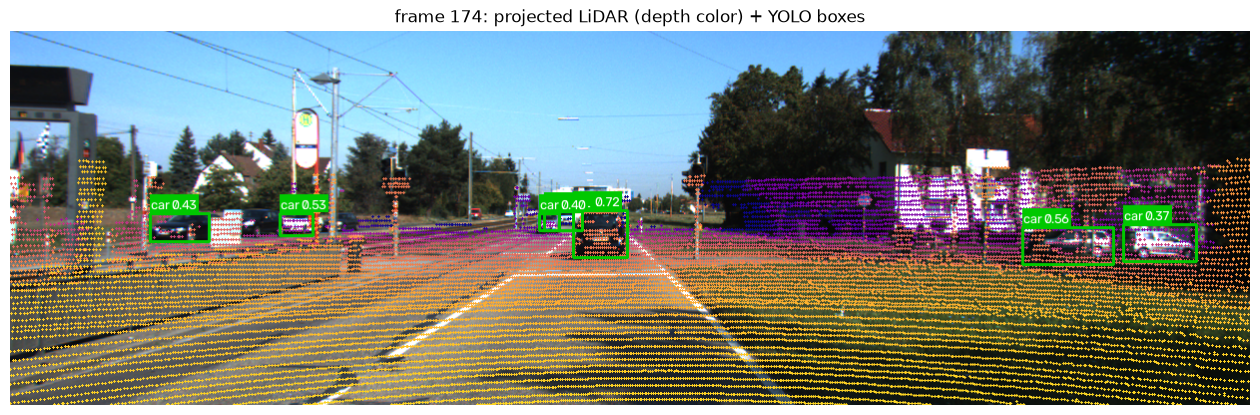

In [2]:
uv, depth, mask = project_velo_to_image(pts, calib, img.shape[:2])
idx = np.flatnonzero(mask)                      # uv[i] 는 원본 점 pts[idx[i]]
print(f"uv {uv.shape} depth {depth.shape} mask {mask.shape} → 이미지 안 점 {mask.sum()} / {len(pts)} ({mask.mean()*100:.1f}%)")
print(f"depth 범위 {depth.min():.1f} ~ {depth.max():.1f} m")

vis = draw_detections(draw_projected_points(img, uv, depth), dets)
plt.figure(figsize=(16, 5)); plt.imshow(vis[:, :, ::-1]); plt.axis("off"); plt.title(f"frame {FRAME}: projected LiDAR (depth color) + YOLO boxes"); plt.show()

## 5.2 박스 안 점 선택 (frustum) 과 배정 점 수

2D 박스를 각 변 10% 씩 줄인 뒤(`box_shrink`), 픽셀 `uv` 가 그 안에 들어오는 점을 고른다.
박스 가장자리는 배경(도로·건물·나무) 이 걸리기 쉬워서 줄인다. 3D 로 보면 카메라 중심에서 박스 네 모서리로 뻗는 사각뿔 = **프러스텀(frustum)** 안의 점이다.

In [3]:
shrink = cfg["fusion"]["box_shrink"]
print(f"{'det':>3} {'class':<5} {'박스 px':>10} {'전체 박스 안':>12} {'축소 박스 안':>12} {'깊이 min':>8} {'p30':>6} {'median':>7} {'mean':>6} {'max':>6}")
box_sel = []
for k, d in enumerate(dets):
    full = uv_in_box(uv, d.xyxy)
    sh = uv_in_box(uv, shrink_box(d.xyxy, shrink))
    box_sel.append(np.flatnonzero(sh))
    w, h = d.xyxy[2] - d.xyxy[0], d.xyxy[3] - d.xyxy[1]
    dd = depth[sh]
    stats = (f"{dd.min():8.1f} {np.percentile(dd, 30):6.1f} {np.median(dd):7.1f} {dd.mean():6.1f} {dd.max():6.1f}" if len(dd) else "")
    print(f"{k:>3} {d.class_name:<5} {w:4.0f}x{h:<4.0f} {full.sum():>12} {sh.sum():>12} {stats}")

det class      박스 px      전체 박스 안      축소 박스 안   깊이 min    p30  median   mean    max
  0 car     54x47            171           97     23.0   23.1    23.1   23.3   24.0
  1 car     91x36            200          112     23.7   24.3    27.5   29.9   39.2
  2 car     33x22             35           30     16.4   47.0    47.2   46.4   49.1
  3 car     38x20             29           20     25.6   47.9    59.5   57.9   70.1
  4 car     59x29             29           25     25.8   34.1    34.2   33.4   37.5
  5 car     20x17             15           13     47.6   47.6    47.7   47.8   48.0
  6 car     72x37            138           83     37.1   37.2    37.3   41.6   51.2


## 5.3 깊이 히스토그램: 전경/배경 오염 (foreground/background contamination)

2D 박스는 물체를 감싸지만 "물체 뒤에 보이는 것" 도 같이 감싼다. det1 (오른쪽 차) 의 박스에는 25 m 차 점과 30~45 m 뒤편 점이 섞여 있다.
- **평균(mean)** 은 배경 점에 끌려간다.
- **중앙값(median)** 은 배경이 절반을 넘지 않으면 버티지만, det1 처럼 40% 오염이면 이미 중심에서 벗어난다.
- **하위 백분위(p30)** 는 "가까운 쪽 30%" 를 대표로 삼아 전경을 우선한다. 뒤에 있는 것이 배경이라는 가정이 깔려 있다.

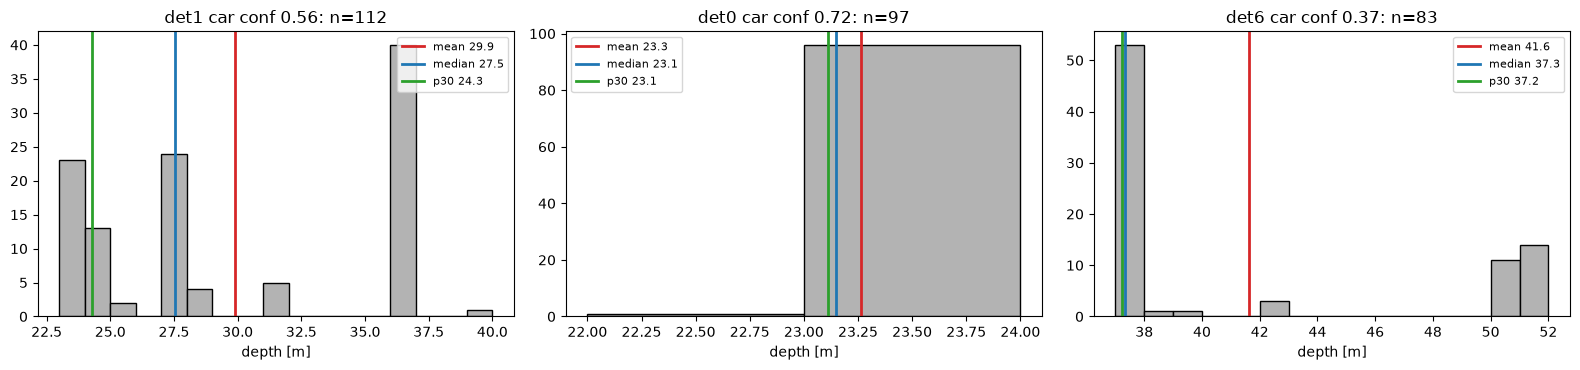

In [4]:
fig, axes = plt.subplots(1, 3, figsize=(16, 3.8))
for ax, k in zip(axes, [1, 0, 6]):
    dd = depth[box_sel[k]]
    ax.hist(dd, bins=np.arange(np.floor(dd.min()), np.ceil(dd.max()) + 1, 1.0), color="0.7", edgecolor="k")
    for val, name, c in [(dd.mean(), "mean", "tab:red"), (np.median(dd), "median", "tab:blue"), (np.percentile(dd, 30, method="nearest"), "p30", "tab:green")]:
        ax.axvline(val, color=c, lw=2, label=f"{name} {val:.1f}")
    ax.set_title(f"det{k} {dets[k].class_name} conf {dets[k].confidence:.2f}: n={len(dd)}"); ax.set_xlabel("depth [m]"); ax.legend(fontsize=8)
plt.tight_layout(); plt.show()

## 5.4 Phase 5 기준선 `fuse_frame_raw`

```
박스 안 점 (축소 박스)  →  대표 깊이 d_rep = 하위 depth_percentile(30%) 값
                       →  |depth − d_rep| ≤ depth_band_m(1.5) 인 점만
                       →  그 점들의 좌표별 중앙값 = center (Velodyne)
```
- 점 0개 → `status = "empty"`, 5개 미만(`min_points`) → `"sparse"`. 이때 `center = None` 이라 다음 단계(추적)가 무시한다.
- 두 박스의 중심이 BEV 에서 1 m 안이면(`dedup_distance_m`) confidence 낮은 쪽을 `"invalid"`(duplicate) 로 바꾼다 (det3/det5 가 그 예).
- `size` 는 없다 (raw 는 위치만).

In [5]:
raw = fuse_frame_raw(pts, dets, calib, img.shape[:2], cfg)
def show(objs):
    print(f"{'det':>3} {'class':<5} {'status':<8} {'reason':<16} {'n_pts':>5}  center (x, y, z) [m]            size (l, w, h) [m]")
    for k, o in enumerate(objs):
        c = "-" if o.center is None else "(" + ", ".join(f"{v:6.2f}" for v in o.center) + ")"
        s = "-" if o.size is None else "(" + ", ".join(f"{v:5.2f}" for v in o.size) + ")"
        print(f"{k:>3} {o.class_name:<5} {o.status:<8} {o.reason:<16} {o.n_points:>5}  {c:<30} {s}")
show(raw)
print("\nGT (FOV 안):")
for b in gts:
    print(f"  gt{b.tracklet_id:<3} {b.object_type:<8} center=({b.center[0]:6.2f}, {b.center[1]:6.2f}, {b.center[2]:5.2f})  l,w,h=({b.size[0]:.2f}, {b.size[1]:.2f}, {b.size[2]:.2f})  yaw={b.yaw:+.2f}")

det class status   reason           n_pts  center (x, y, z) [m]            size (l, w, h) [m]
  0 car   ok                           97  ( 23.43,   0.67,  -0.97)       -
  1 car   ok                           38  ( 24.21, -13.90,  -1.51)       -
  2 car   ok                           28  ( 47.45,  21.19,  -0.88)       -
  3 car   ok                            9  ( 48.19,   4.57,  -0.81)       -
  4 car   ok                           13  ( 34.43,  21.26,  -0.86)       -
  5 car   invalid  duplicate_of_3      13  -                              -
  6 car   ok                           53  ( 37.54, -27.81,  -2.42)       -

GT (FOV 안):
  gt12  Car      center=( 49.25,   4.77, -0.83)  l,w,h=(3.11, 1.43, 1.47)  yaw=-3.14
  gt13  Car      center=( 42.65,  21.33, -0.58)  l,w,h=(4.06, 1.44, 1.71)  yaw=+3.14
  gt14  Car      center=( 49.22,  21.56, -0.68)  l,w,h=(3.88, 1.67, 1.53)  yaw=+3.13
  gt15  Car      center=( 37.32, -22.96, -1.95)  l,w,h=(4.26, 1.39, 1.68)  yaw=+1.62
  gt16  Car      cent

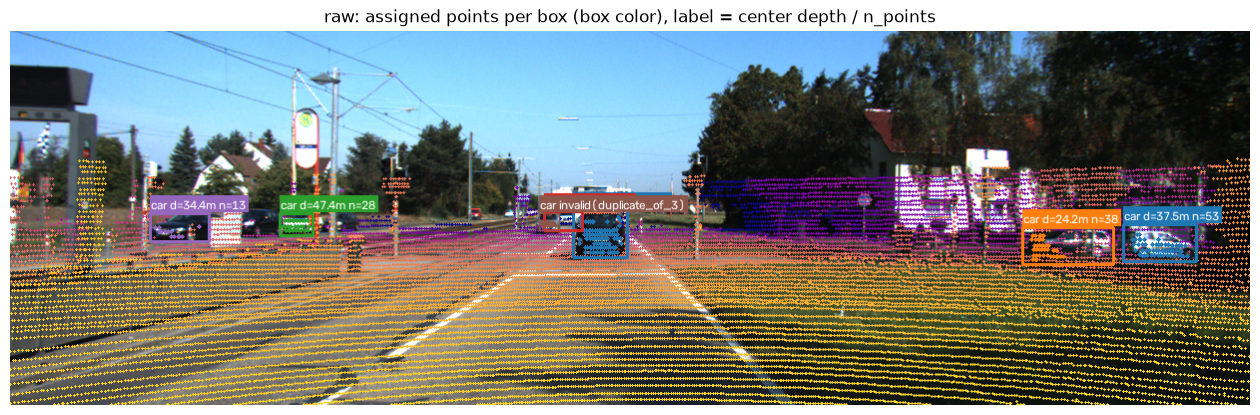

In [6]:
vis = draw_fusion(img, uv, depth, raw, mask=mask)
plt.figure(figsize=(16, 5)); plt.imshow(vis[:, :, ::-1]); plt.axis("off"); plt.title("raw: assigned points per box (box color), label = center depth / n_points"); plt.show()

BEV 로 보면 raw 중심(빨간 ×)이 GT 박스(초록)의 **뒷면(센서 쪽 면)** 에 붙어 있다. LiDAR 는 보이는 면만 찍기 때문이다.
이 "표면 ≠ 중심" 편향이 이 시퀀스에서 약 −1.3 m (전 프레임 평균) 로, raw 의 가장 큰 오차 원인이다.

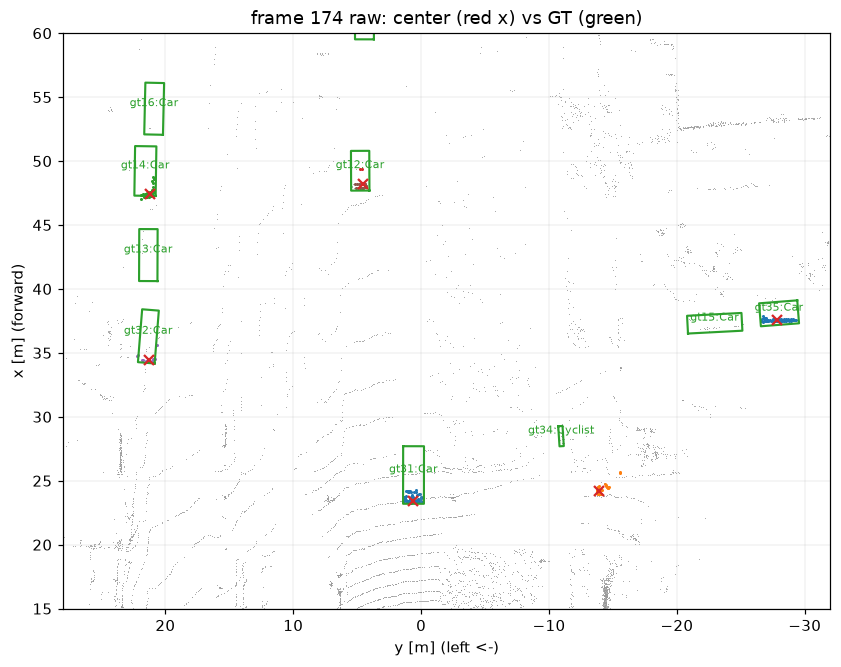

In [7]:
from IPython.display import Image, display
p = plot_bev_objects(pts, raw, f"{cfg['outputs']['dir']}/phase5/nb_frame{FRAME}_bev_raw.png", gt=gts, xlim=(15, 60), ylim=(-32, 28), title=f"frame {FRAME} raw: center (red x) vs GT (green)")
display(Image(filename=str(p), width=700))

## 6.1 Phase 6 단계별 점 수 변화: ROI → 지면 제거 → 프러스텀 → DBSCAN

| 단계 | 하는 일 | 왜 |
|---|---|---|
| ROI | x ∈ [0, 70], \|y\| ≤ 40, z ∈ [−3, 3] (Velodyne, m) | 카메라 뒤·너무 먼 점 제거, RANSAC 속도 |
| 지면 제거 | Open3D `segment_plane` (RANSAC): 평면 `ax + by + cz + d = 0` 에서 0.2 m 안 점 = 지면 | 박스 아래쪽에 걸리는 도로 점이 클러스터를 물체와 이어 붙이는 것을 막음 |
| 프러스텀 | 축소 박스 안 + (ROI ∧ 비지면) 점 | 후보 축소 |
| DBSCAN | eps 0.8 m, min_points 5 → 덩어리 라벨, −1 = noise | 앞 물체와 뒤 배경을 공간적으로 분리 |

Velodyne 은 지면에서 1.73 m 높이에 있으므로 평면의 z 절편 `−d/c` 가 −1.7 근방이면 정상이다.

전체 119911 → ROI 61669 → 비지면 21717   평면 [a,b,c,d] = [     -0.002      -0.006           1       1.661],  원점 아래 지면 z = -1.66 m

det     축소박스    +ROI·비지면    클러스터 수  noise    최대 클러스터
  0       97          84         1      0         84
  1      112          77         3      8         34
  2       30          30         1      2         28
  3       20          10         1      3          7
  4       25          25         3      2         12
  5       13          13         1      0         13
  6       83          55         2      4         45


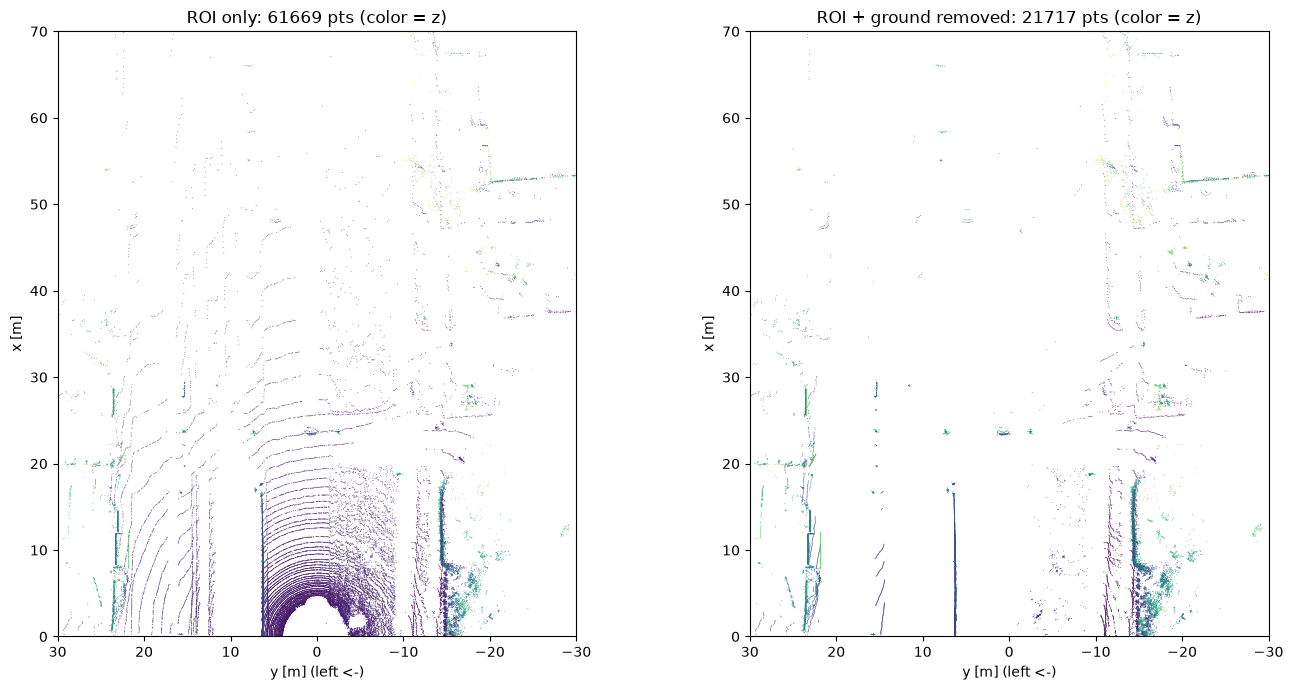

In [8]:
f = cfg["fusion"]
p3 = pts[:, :3].astype(np.float64)
roi = roi_filter(p3, f["roi"])
non_ground, plane = remove_ground(p3[roi], f["ground"])
keep = np.zeros(len(p3), bool); keep[np.flatnonzero(roi)[non_ground]] = True
print(f"전체 {len(p3)} → ROI {roi.sum()} → 비지면 {keep.sum()}   평면 [a,b,c,d] = {np.round(plane, 3)},  원점 아래 지면 z = {-plane[3]/plane[2]:.2f} m")
keep_uv = keep[idx]
print(f"\n{'det':>3} {'축소박스':>8} {'+ROI·비지면':>11} {'클러스터 수':>9} {'noise':>6} {'최대 클러스터':>10}")
for k, d in enumerate(dets):
    sel = np.flatnonzero(uv_in_box(uv, shrink_box(d.xyxy, f["box_shrink"])) & keep_uv)
    lab = cluster_points(p3[idx[sel]], f["cluster"]) if len(sel) else np.zeros(0, int)
    n_cl = int(lab.max() + 1) if len(lab) else 0
    biggest = max(((lab == c).sum() for c in range(n_cl)), default=0)
    print(f"{k:>3} {len(box_sel[k]):>8} {len(sel):>11} {n_cl:>9} {(lab == -1).sum():>6} {biggest:>10}")

fig, axes = plt.subplots(1, 2, figsize=(14, 7))
for ax, (m, title) in zip(axes, [(roi, "ROI only"), (keep, "ROI + ground removed")]):
    q = p3[m]; q = q[np.random.default_rng(0).choice(len(q), min(len(q), 40000), replace=False)]
    ax.scatter(q[:, 1], q[:, 0], s=0.3, c=q[:, 2], cmap="viridis", vmin=-2, vmax=2, linewidths=0)
    ax.set_xlim(30, -30); ax.set_ylim(0, 70); ax.set_aspect("equal"); ax.set_title(f"{title}: {m.sum()} pts (color = z)"); ax.set_xlabel("y [m] (left <-)"); ax.set_ylabel("x [m]")
plt.tight_layout(); plt.show()

## 6.2 DBSCAN 클러스터와 선택 규칙

프러스텀 안 점을 DBSCAN 으로 나누면 보통 "물체 덩어리 + 뒤 배경 덩어리 + noise" 가 된다. 어느 것을 고를지가 관건이다.
- `largest` (기본): 점이 가장 많은 덩어리. 전 프레임 스윕에서 GT 매칭이 가장 많았다 (926 vs nearest 884).
- `nearest`: 깊이 중앙값이 가장 작은 덩어리 (`cluster_min_ratio` 로 너무 작은 덩어리는 제외).

det0 (25 m 앞차) 은 어느 규칙이든 같지만, det6 (오른쪽 멀리, 37 m) 은 **largest 가 51 m 의 배경 덩어리를 고른다** → 실패 사례.

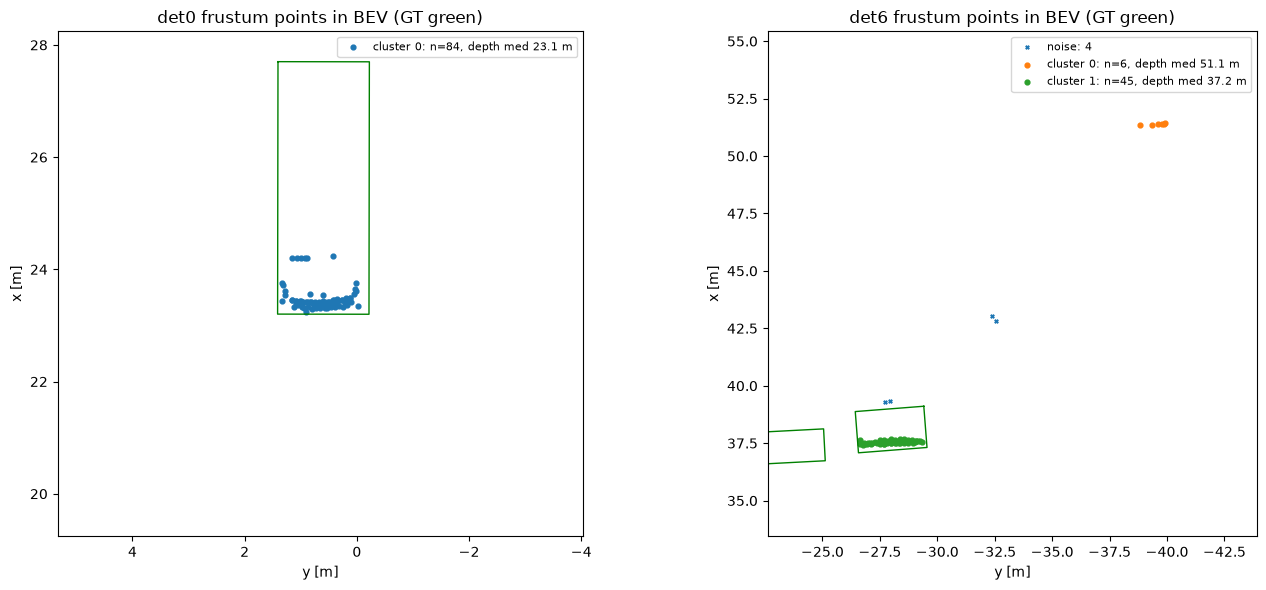

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
for ax, k in zip(axes, [0, 6]):
    d = dets[k]
    sel = np.flatnonzero(uv_in_box(uv, shrink_box(d.xyxy, f["box_shrink"])) & keep_uv)
    q, dd = p3[idx[sel]], depth[sel]
    lab = cluster_points(q, f["cluster"])
    for c in sorted(set(lab)):
        m = lab == c
        ax.scatter(q[m, 1], q[m, 0], s=12 if c >= 0 else 6, marker="o" if c >= 0 else "x",
                   label=f"cluster {c}: n={m.sum()}, depth med {np.median(dd[m]):.1f} m" if c >= 0 else f"noise: {m.sum()}")
    for b in gts:
        cc = box_corners_bev(b.center, b.size, b.yaw); cc = np.vstack([cc, cc[:1]]); ax.plot(cc[:, 1], cc[:, 0], "g-", lw=1)
    ax.set_xlim(q[:, 1].max() + 4, q[:, 1].min() - 4); ax.set_ylim(q[:, 0].min() - 4, q[:, 0].max() + 4)
    ax.set_aspect("equal"); ax.legend(fontsize=8); ax.set_title(f"det{k} frustum points in BEV (GT green)"); ax.set_xlabel("y [m]"); ax.set_ylabel("x [m]")
plt.tight_layout(); plt.show()

## 6.3 표면 → 중심 오프셋 (surface-to-center offset)

클러스터 중앙값은 **보이는 면 위의 점** 이다. 앞차라면 뒷면이므로 실제 중심은 차 길이의 절반(≈ 2 m) 만큼 더 앞에 있다.

```
u      = c_xy / |c_xy|                      센서(원점) → 물체 방향 단위벡터 (BEV)
extent = max(p·u) − min(p·u)                클러스터 점을 u 에 투영한 퍼짐 (이미 보이는 깊이)
push   = max(0, half_depth[class] − extent/2)
c_xy  += u · push
```
`half_depth` 는 클래스별 prior (car 2.0 m: KITTI Car 길이 평균 ≈ 4 m). 옆면까지 보이면(extent 큼) 덜 민다.
한계: YOLO 가 클래스를 틀리면(Van → car) prior 가 틀린다. 전 프레임 ablation: 오프셋 없이 BEV 오차 1.39 m → 오프셋 후 0.63 m.

In [10]:
import copy
cfg_off = copy.deepcopy(cfg); cfg_off["fusion"]["surface_offset"]["enable"] = False
clu_off = fuse_frame_clustered(pts, dets, calib, img.shape[:2], cfg_off)
clu = fuse_frame_clustered(pts, dets, calib, img.shape[:2], cfg)

def nearest_gt(c):
    if c is None or not gts: return None, np.nan
    d = [np.linalg.norm(c[:2] - b.center[:2]) for b in gts]
    j = int(np.argmin(d)); return gts[j], d[j]

print(f"{'det':>3} {'raw x':>7} {'clu(no off) x':>13} {'clu(off) x':>10} {'GT x':>7} {'GT id':>6} | BEV err raw / no-off / off [m]")
for k in range(len(dets)):
    r, a, b = raw[k], clu_off[k], clu[k]
    g, _ = nearest_gt(b.center if b.center is not None else (r.center if r.center is not None else None))
    def x(o): return f"{o.center[0]:7.2f}" if o.center is not None else f"{o.status:>7}"
    def e(o): return f"{np.linalg.norm(o.center[:2] - g.center[:2]):5.2f}" if (o.center is not None and g is not None) else "  -  "
    print(f"{k:>3} {x(r)} {x(a):>13} {x(b):>10} {g.center[0] if g else np.nan:7.2f} {('gt%d' % g.tracklet_id) if g else '-':>6} | {e(r)} / {e(a)} / {e(b)}")
print("\n(det1 은 GT 가 없는 곳 — tracklet 라벨이 없는 주차 차량 또는 오검출. det6 은 largest 규칙이 배경을 골라 51 m 로 튄 실패 사례)")

det   raw x clu(no off) x clu(off) x    GT x  GT id | BEV err raw / no-off / off [m]
  0   23.43         23.42      24.92   25.45   gt31 |  2.03 /  2.03 /  0.54
  1   24.21         37.00      37.93   37.32   gt15 | 15.93 /  0.33 /  0.78
  2   47.45         47.45      48.68   49.22   gt14 |  1.82 /  1.82 /  0.57
  3   48.19         48.03      49.86   49.25   gt12 |  1.07 /  1.24 /  0.62
  4   34.43         34.43      35.72   36.29   gt32 |  1.86 /  1.86 /  0.99
  5 invalid       invalid    invalid     nan      - |   -   /   -   /   -  
  6   37.54         37.53      38.45   38.09   gt35 |  0.59 /  0.57 /  0.78

(det1 은 GT 가 없는 곳 — tracklet 라벨이 없는 주차 차량 또는 오검출. det6 은 largest 규칙이 배경을 골라 51 m 로 튄 실패 사례)


## 6.4 최종 3D 박스: AABB 와 OBB

- **AABB** (axis-aligned): 클러스터 점의 x/y/z min–max. yaw = 0. 비스듬한 물체는 박스가 커진다.
- **OBB** (`use_obb: true`): BEV 에서 PCA 로 점이 가장 길게 퍼진 방향을 yaw 로 잡고, 그 방향으로 min–max.
  LiDAR 는 보이는 면만 찍어 L 자 모양이므로 PCA 방향이 진행 방향과 다를 수 있다 (특히 멀리서 뒷면만 보일 때는 **폭 방향** 이 최대 분산 → yaw ≈ ±90°).

멀리(40 m 이상) 있는 차는 점이 10~30 개라 크기가 실제(4 × 1.8 m) 보다 훨씬 작게 나온다. **크기 추정은 이 시퀀스에서 신뢰하기 어렵다** — 위치(중심) 가 이 단계의 주 산출물이다.

AABB (use_obb=false):
det class status   reason           n_pts  center (x, y, z) [m]            size (l, w, h) [m]
  0 car   ok                           84  ( 24.92,   0.72,  -0.84)       ( 1.00,  1.36,  0.95)
  1 car   ok                           34  ( 37.93, -23.44,  -2.13)       ( 0.36,  3.01,  1.07)
  2 car   ok                           28  ( 48.68,  21.74,  -0.88)       ( 1.72,  1.04,  0.65)
  3 car   ok                            7  ( 49.86,   4.75,  -1.05)       ( 0.33,  0.45,  0.24)
  4 car   ok                           12  ( 35.72,  22.13,  -0.86)       ( 0.49,  1.42,  0.43)
  5 car   invalid  duplicate_of_3      13  -                              -
  6 car   ok                           45  ( 38.45, -28.69,  -2.44)       ( 0.23,  2.71,  0.64)

OBB (use_obb=true): yaw [deg]
  det0: size=(1.41, 1.07, 0.95) yaw= +81.2°  n=84
  det1: size=(3.03, 0.29, 1.07) yaw= -85.3°  n=34
  det2: size=(1.95, 0.73, 0.65) yaw= -30.4°  n=28
  det3: size=(0.48, 0.38, 0.24) yaw= +74.3°  n=7
  

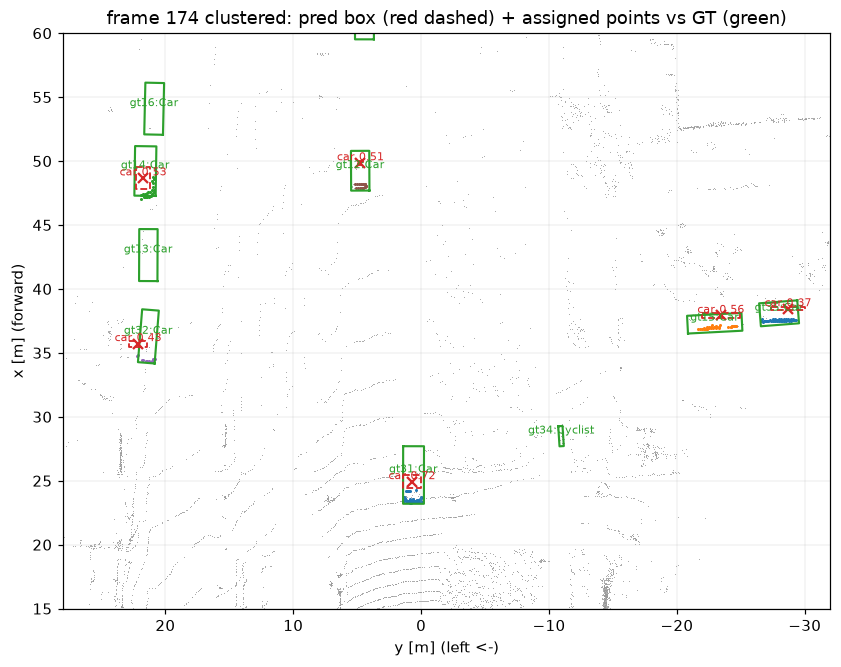

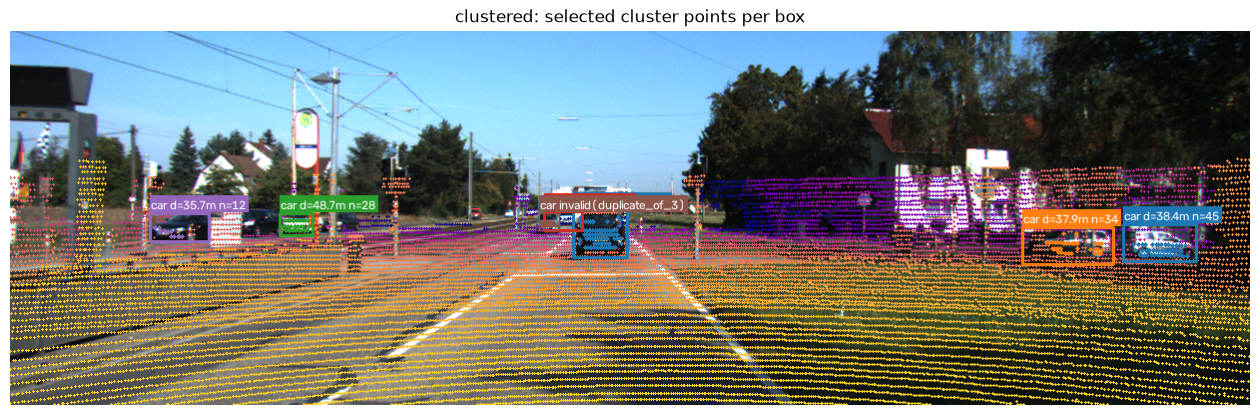

In [11]:
cfg_obb = copy.deepcopy(cfg); cfg_obb["fusion"]["use_obb"] = True
clu_obb = fuse_frame_clustered(pts, dets, calib, img.shape[:2], cfg_obb)
print("AABB (use_obb=false):"); show(clu)
print("\nOBB (use_obb=true): yaw [deg]")
for k, o in enumerate(clu_obb):
    if o.center is not None:
        print(f"  det{k}: size=({o.size[0]:.2f}, {o.size[1]:.2f}, {o.size[2]:.2f}) yaw={np.degrees(o.yaw):+6.1f}°  n={o.n_points}")
p = plot_bev_objects(pts, clu, f"{cfg['outputs']['dir']}/phase6/nb_frame{FRAME}_bev_clustered.png", gt=gts, xlim=(15, 60), ylim=(-32, 28), title=f"frame {FRAME} clustered: pred box (red dashed) + assigned points vs GT (green)")
display(Image(filename=str(p), width=700))
vis = draw_fusion(img, uv, depth, clu, mask=mask)
plt.figure(figsize=(16, 5)); plt.imshow(vis[:, :, ::-1]); plt.axis("off"); plt.title("clustered: selected cluster points per box"); plt.show()

## 6.5 GT 와 수치 비교

`scripts/compare_fusion.py` 의 `evaluate_objects` 로 이 프레임과 전체 297 프레임을 평가한다.
매칭 = BEV 중심 거리 ≤ 2 m 헝가리안 1:1. 깊이 bias = mean(pred_x − gt_x).

In [12]:
sys.path.insert(0, f"{cfg['outputs']['dir']}/../scripts")
from compare_fusion import evaluate_objects
from perceptrack3d.fusion.frustum_fusion import load_objects_json

def row(name, r):
    c, d = r["center"], r["depth"]
    return f"{name:<28} GT={r['n_gt']:4d} ok={r['n_pred_ok']:4d} matched={r['n_matched']:4d} R={r['recall']:.2f} P={r['precision']:.2f} BEV mean={c['mean_bev']:.2f} median={c['median_bev']:.2f} depth bias={d['bias']:+.2f}"
print(f"--- frame {FRAME} ---")
print(row("raw", evaluate_objects({FRAME: raw}, gts_all, cfg, 2.0)))
print(row("clustered (no offset)", evaluate_objects({FRAME: clu_off}, gts_all, cfg, 2.0)))
print(row("clustered", evaluate_objects({FRAME: clu}, gts_all, cfg, 2.0)))
print("--- all 297 frames (outputs/phase5,6 JSON) ---")
print(row("raw", evaluate_objects(load_objects_json(f"{cfg['outputs']['dir']}/phase5/objects_raw.json"), gts_all, cfg, 2.0)))
print(row("clustered", evaluate_objects(load_objects_json(f"{cfg['outputs']['dir']}/phase6/objects_clustered.json"), gts_all, cfg, 2.0)))

--- frame 174 ---
raw                          GT=  10 ok=   6 matched=   4 R=0.40 P=0.67 BEV mean=1.33 median=1.44 depth bias=-1.31
clustered (no offset)        GT=  10 ok=   6 matched=   5 R=0.50 P=0.83 BEV mean=1.16 median=1.24 depth bias=-1.15
clustered                    GT=  10 ok=   6 matched=   6 R=0.60 P=1.00 BEV mean=0.71 median=0.70 depth bias=-0.01
--- all 297 frames (outputs/phase5,6 JSON) ---
raw                          GT=1394 ok=1175 matched= 621 R=0.45 P=0.53 BEV mean=1.45 median=1.48 depth bias=-1.29
clustered                    GT=1394 ok=1107 matched= 926 R=0.66 P=0.84 BEV mean=0.63 median=0.56 depth bias=-0.30


## 6.6 실패 사례

| 사례 | 프레임 / 검출 | 무슨 일 | 대응 |
|---|---|---|---|
| 빈 박스 (empty) | frame 50 det1 (car 0.41, 29×17 px, ~45 m) | 축소 박스 안에 LiDAR 점이 0개. 멀고 작은 물체는 링 간격(0.4 m 이상) 사이로 빠진다 | `status="empty"` 로 명시, 추적기가 무시 |
| 희소 (sparse) | 전 프레임 61건 | 1~4 점 → 중심을 믿을 수 없음 | `min_points` 미만이면 `"sparse"` |
| 겹친 박스 (duplicate) | frame 174 det3/det5 | 같은 차에 car 박스 2개 → 3D 중심이 0.2 m 차이 | BEV 거리 < 1 m 면 낮은 conf 를 `"invalid"` |
| 클러스터 오선택 | frame 174 det6 | largest 가 배경 덩어리를 고름 (37 m → 51 m) | `cluster_select: nearest` + `cluster_min_ratio` 로 바꿀 수 있음 (전체 성능은 largest 가 우세) |
| 잘린 박스 (truncated) | frame 201 det0 (x1 = 0) | 화면 밖으로 나가는 차 → 박스 중심 ≠ 물체 중심, 표면 오프셋도 부정확 | `truncated=True` 플래그, 평가 시 분리 가능 |
| 배경 오염 | frame 174 det1 | 박스 안 점의 40% 가 뒤쪽 | p30 + 밴드(raw), DBSCAN(clustered) |

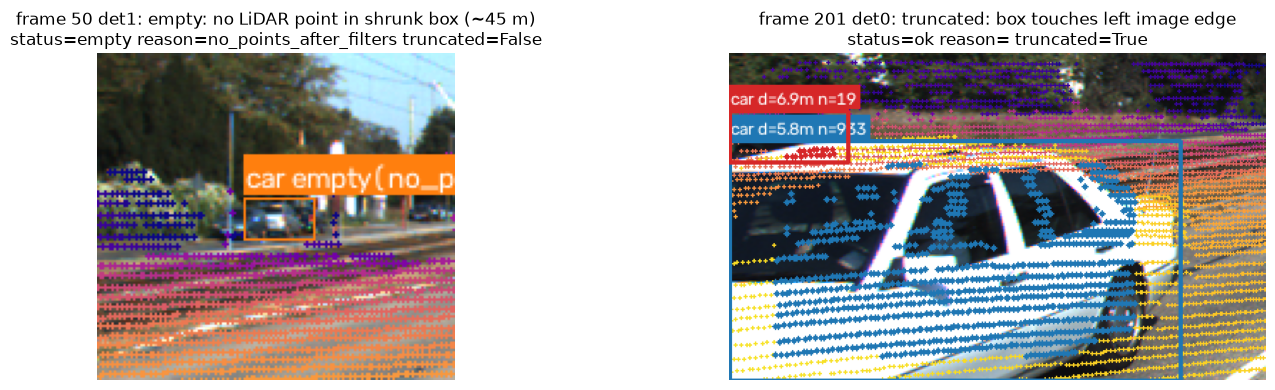

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(16, 4))
for ax, (fid, k, title) in zip(axes, [(50, 1, "empty: no LiDAR point in shrunk box (~45 m)"), (201, 0, "truncated: box touches left image edge")]):
    fr2 = ds.load_frame(fid); uv2, d2, m2 = project_velo_to_image(fr2["points"], calib, fr2["image"].shape[:2])
    objs2 = fuse_frame_clustered(fr2["points"], dets_all[fid], calib, fr2["image"].shape[:2], cfg)
    vis2 = draw_fusion(fr2["image"], uv2, d2, objs2, mask=m2)
    x1, y1, x2, y2 = dets_all[fid][k].xyxy
    pad = 60; crop = vis2[max(0, int(y1) - pad):int(y2) + pad, max(0, int(x1) - pad):int(x2) + pad]
    ax.imshow(crop[:, :, ::-1]); ax.axis("off"); ax.set_title(f"frame {fid} det{k}: {title}\nstatus={objs2[k].status} reason={objs2[k].reason} truncated={objs2[k].truncated}")
plt.tight_layout(); plt.show()

## 자가 점검 질문

1. 2D 박스 안의 LiDAR 점으로 중심을 구할 때 **평균** 대신 **하위 백분위 + 중앙값** 을 쓰는 이유는? 그 방법이 실패하는 상황(배경 점 비율)은?
2. `remove_ground` 가 돌려주는 평면 계수 `[a, b, c, d]` 에서 "원점 아래 지면 높이" 를 어떻게 계산하는가? KITTI 에서 그 값이 얼마여야 정상인가?
3. 클러스터 중앙값이 GT 중심보다 약 2 m **가깝게** 나오는 이유는? 표면 오프셋 수식에서 `extent/2` 를 빼는 이유는? 클래스 prior 가 틀리면 오차가 얼마나 생기나?

다음: Phase 7 (`notebooks/06_multi_object_tracking.ipynb`) 에서 이 `Object3D` 들을 프레임 순서대로 칼만 필터 추적기에 넣는다. `scripts/run_pipeline.py --variant tracked` 가 전체 파이프라인이다.